DIVYA KASALE
MCA2302102
Assignment 1 : Result Analysis and Student Performance Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df=pd.read_excel(r"C:\Users\Divya\Downloads\Result Analysis.xlsx")
df

,Rollno,Name,Internal,End Term,Total of FM,Internal.1,End Term.1,Total of DBMS,Internal.2,End Term.2,...,Total of EVS,Internal.4,End Term.4,Total of IET,Internal.5,End Term.5,Total of Indian Economics,Internal.6,End Term.6,Total of Spreadsheet
0,BBA22006,Sharayu Dhale,26,55,81,25,60,85,22,40,...,93,22,61,83,26,64,90,25,62,87
1,BBA22016,Vikramkumar,24,50,74,26,55,81,23,65,...,76,26,56,82,21,58,79,25,58,83
2,BBA22030,Vidhi Assudani,25,65,90,25,48,73,22,58,...,80,21,62,83,20,65,85,28,45,73
3,BBA22033,Lav Choudhary,20,52,72,23,52,75,20,64,...,81,19,50,69,19,49,68,27,62,89
4,BBA22038,Nisha Shaw,21,52,73,18,48,66,25,52,...,69,18,45,63,24,65,89,21,50,71
5,BBA22041,Shivam Kumar,25,67,92,16,52,68,24,42,...,66,14,65,79,25,65,90,20,38,58
6,BBA22042,Aryan Phale,26,45,71,19,65,84,26,49,...,86,15,56,71,21,62,83,29,36,65
7,BBA22043,Sundaram,28,50,78,20,40,60,22,45,...,83,28,55,83,25,55,80,24,69,93
8,BBA22044,Sneha Sinha,25,55,80,20,46,66,28,56,...,79,20,41,61,21,43,64,25,45,70
9,BBA22053,Mishruti Patel,20,56,76,29,62,91,22,68,...,74,25,67,92,27,55,82,21,44,65


In [4]:
internal_columns = [col for col in df.columns if 'Internal' in col]
end_term_columns = [col for col in df.columns if 'End Term' in col]
total_scores_columns = [col for col in df.columns if 'Total' in col]

1 . Distribution of Scores:

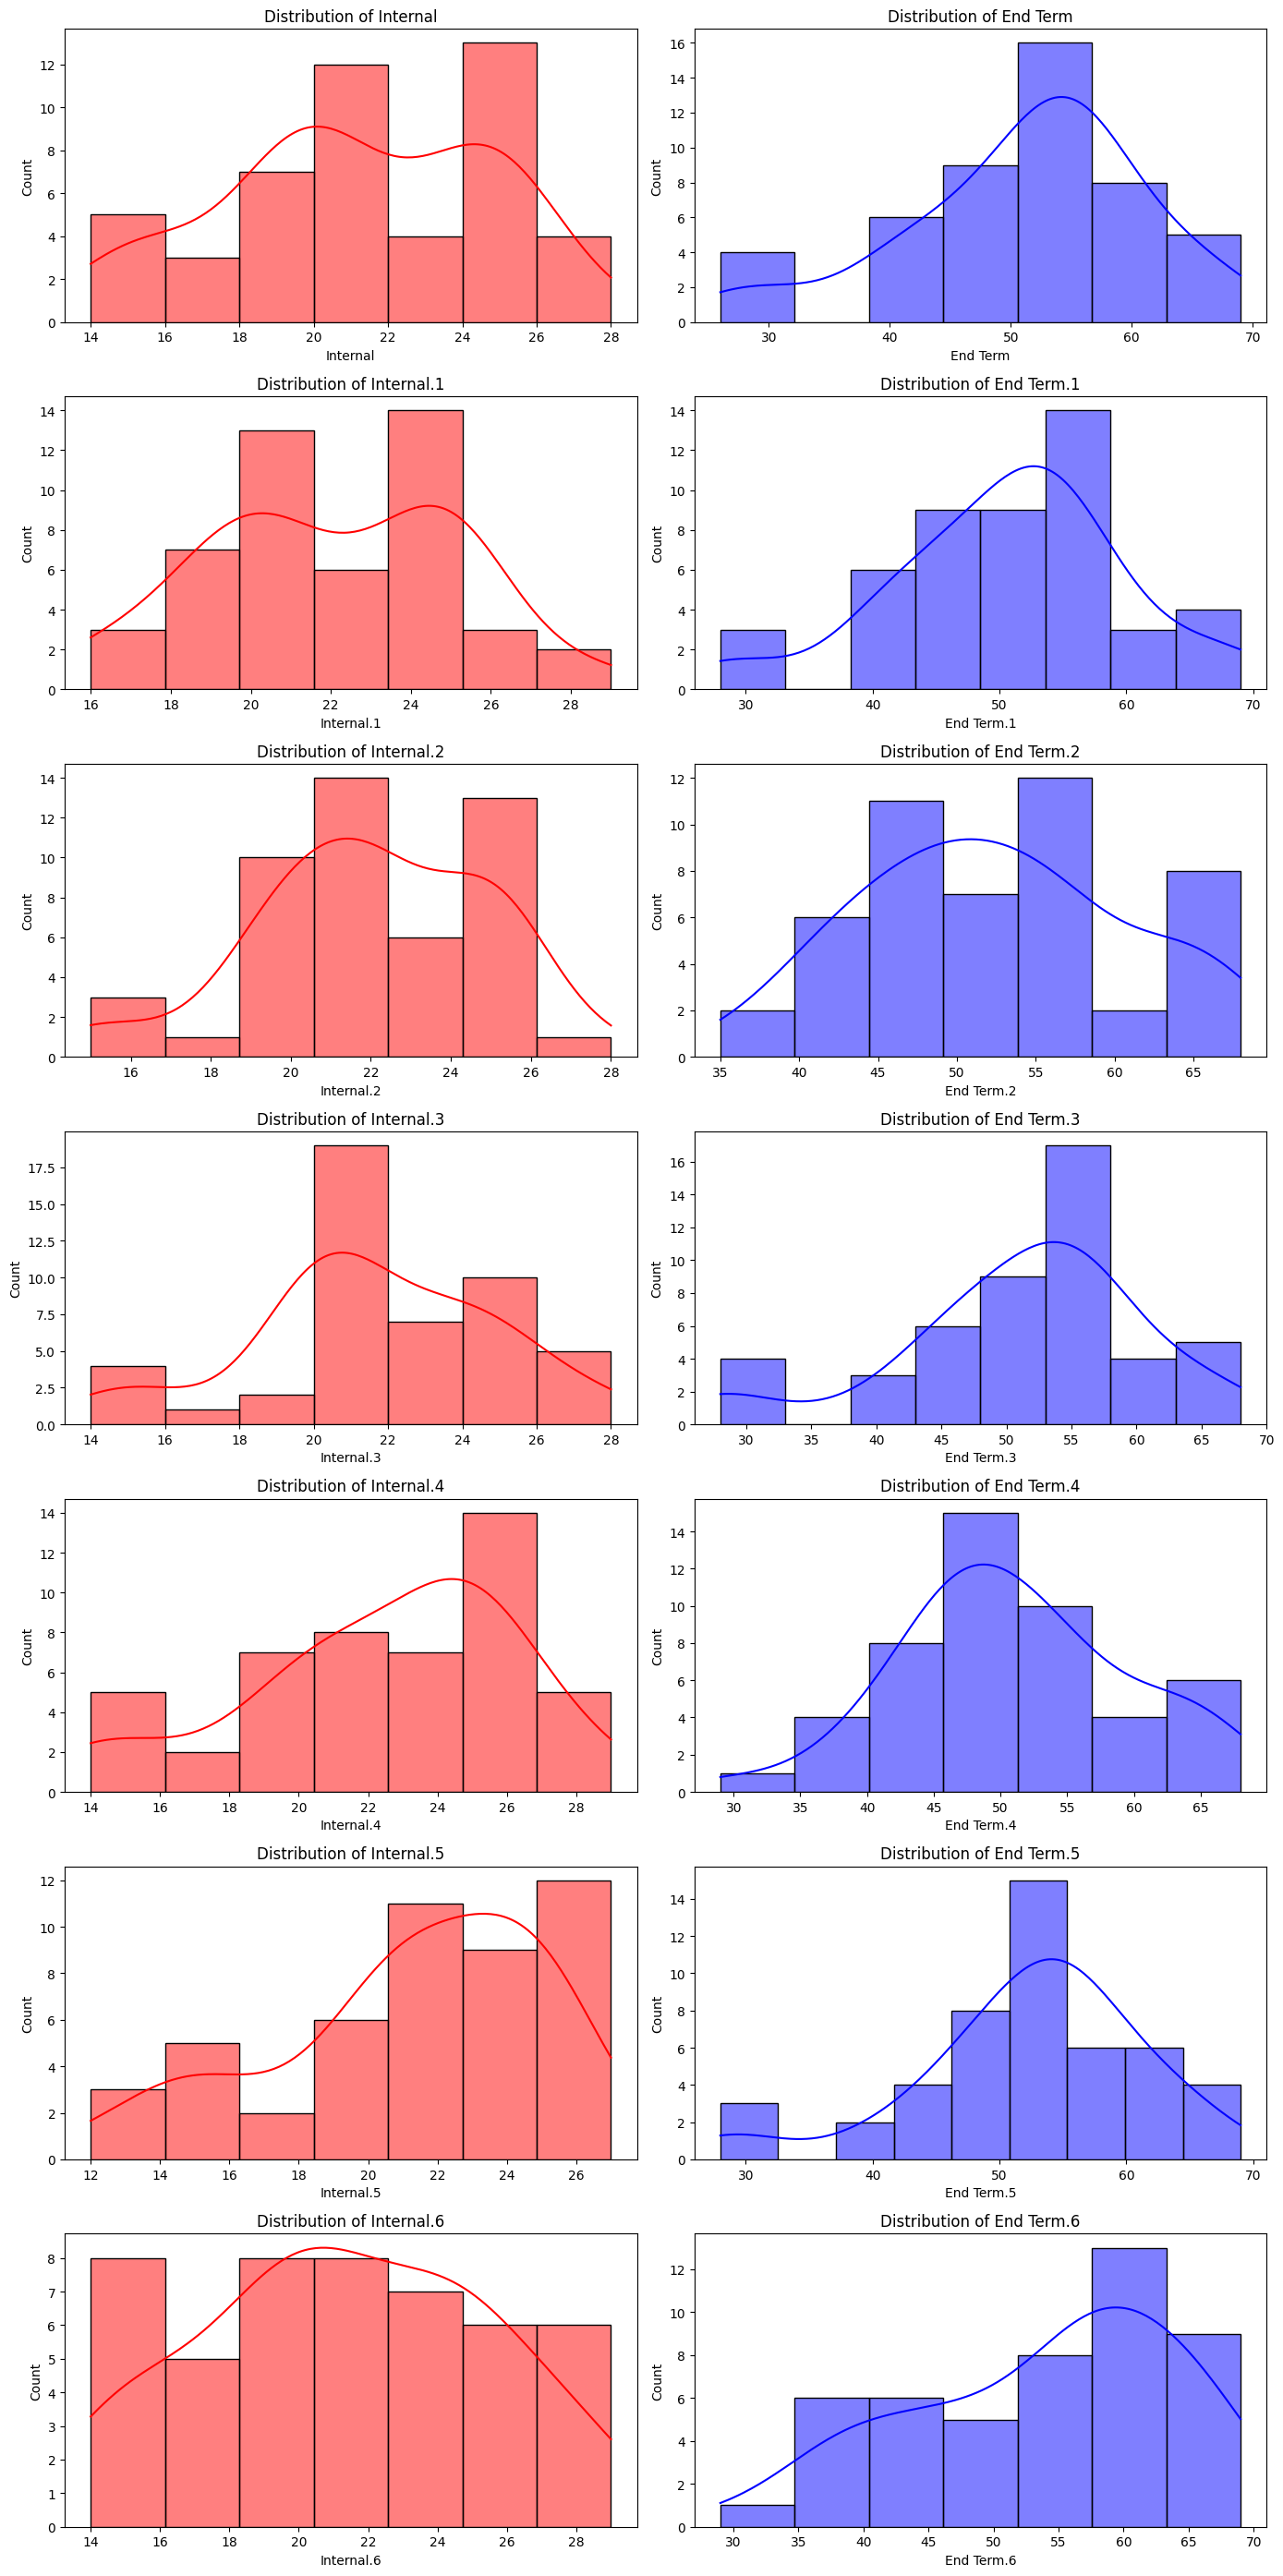

In [5]:
fig, axes = plt.subplots(len(internal_columns), 2, figsize=(14, len(internal_columns) * 4))
for i, (internal_col, end_term_col) in enumerate(zip(internal_columns, end_term_columns)):
    sns.histplot(df[internal_col], kde=True, ax=axes[i, 0], color='Red')
    axes[i, 0].set_title(f'Distribution of {internal_col}')
    sns.histplot(df[end_term_col], kde=True, ax=axes[i, 1], color='blue')
    axes[i, 1].set_title(f'Distribution of {end_term_col}')
plt.tight_layout()
plt.show()

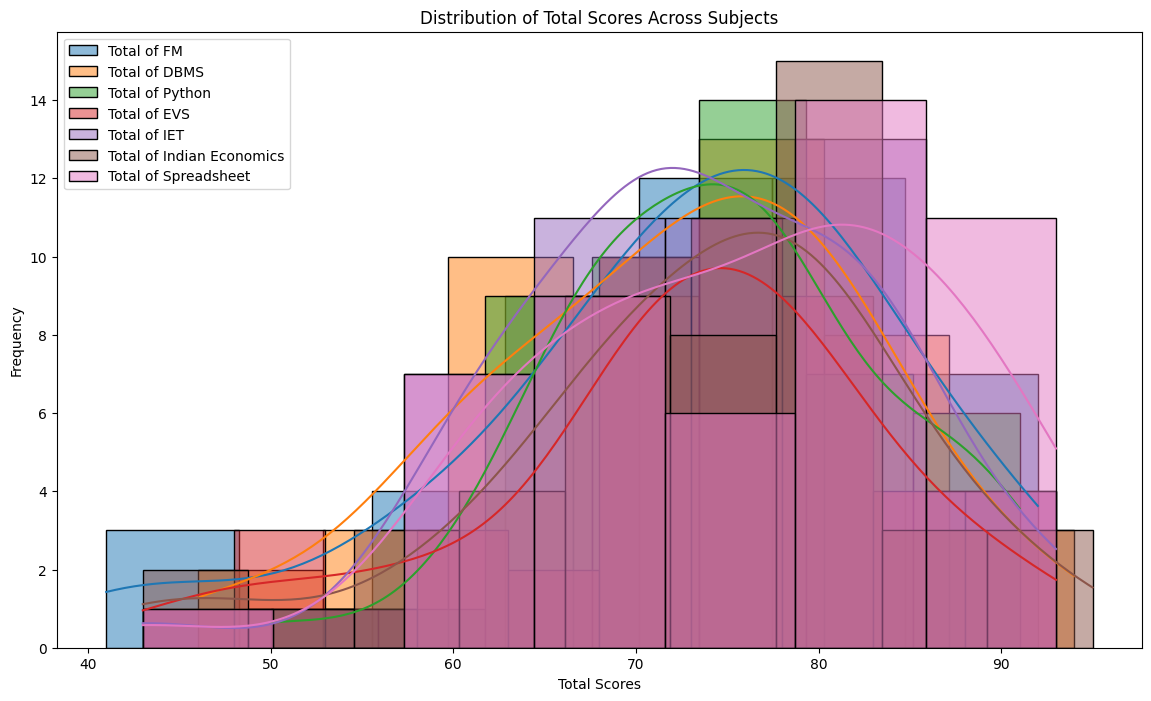

In [6]:
totals_df = df[total_scores_columns]
plt.figure(figsize=(14, 8))
for col in totals_df.columns:
    sns.histplot(totals_df[col], kde=True, label=col)
plt.title('Distribution of Total Scores Across Subjects')
plt.xlabel('Total Scores')
plt.ylabel('Frequency')
plt.legend()
plt.show()

2 . Comparative Analysis:

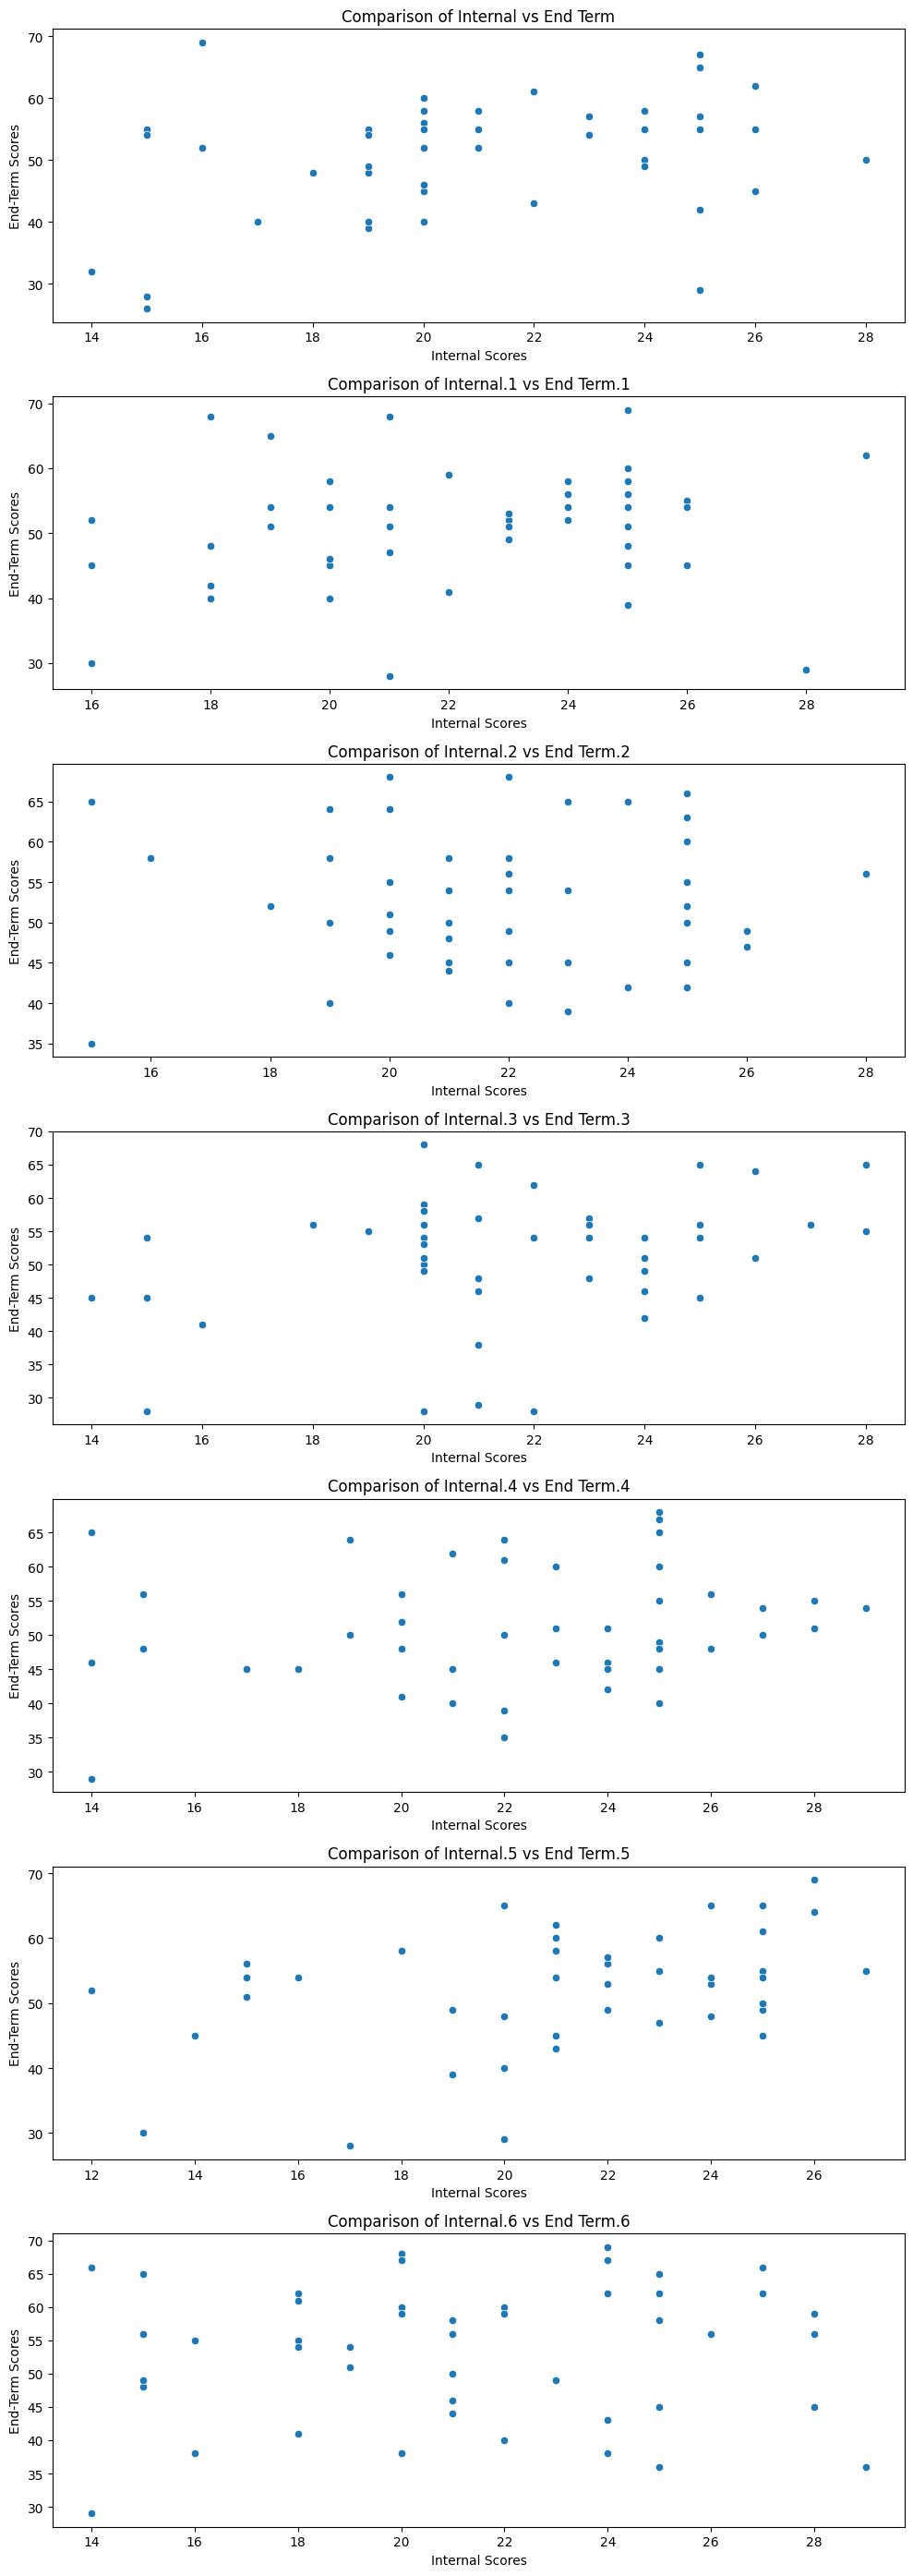

In [7]:
fig, axes = plt.subplots(len(internal_columns), 1, figsize=(10, len(internal_columns) * 4))
for i, (internal_col, end_term_col) in enumerate(zip(internal_columns, end_term_columns)):
    sns.scatterplot(x=df[internal_col], y=df[end_term_col], ax=axes[i])
    axes[i].set_title(f'Comparison of {internal_col} vs {end_term_col}')
    axes[i].set_xlabel('Internal Scores')
    axes[i].set_ylabel('End-Term Scores')
plt.tight_layout()
plt.show()

In [8]:
avg_total_scores = totals_df.mean()
highest_avg_subject = avg_total_scores.idxmax()
highest_avg_score = avg_total_scores.max()

print(f'The subject with the highest average total score : {highest_avg_subject} with a score of {highest_avg_score}')

The subject with the highest average total score : Total of Spreadsheet with a score of 75.9375


3 . Correlation Analysis

In [9]:
correlations = {}
for internal_col, end_term_col in zip(internal_columns, end_term_columns):
    correlation = df[[internal_col, end_term_col]].corr().iloc[0, 1]
    correlations[f'{internal_col} vs {end_term_col}'] = correlation
print('Correlations between internal and end-term scores:', correlations)

Correlations between internal and end-term scores: {'Internal vs End Term': 0.36688550276904286, 'Internal.1 vs End Term.1': 0.17372846837082717, 'Internal.2 vs End Term.2': -0.041406786328088266, 'Internal.3 vs End Term.3': 0.29094964962397224, 'Internal.4 vs End Term.4': 0.16868307426526583, 'Internal.5 vs End Term.5': 0.3772223844567904, 'Internal.6 vs End Term.6': 0.06682394781949837}


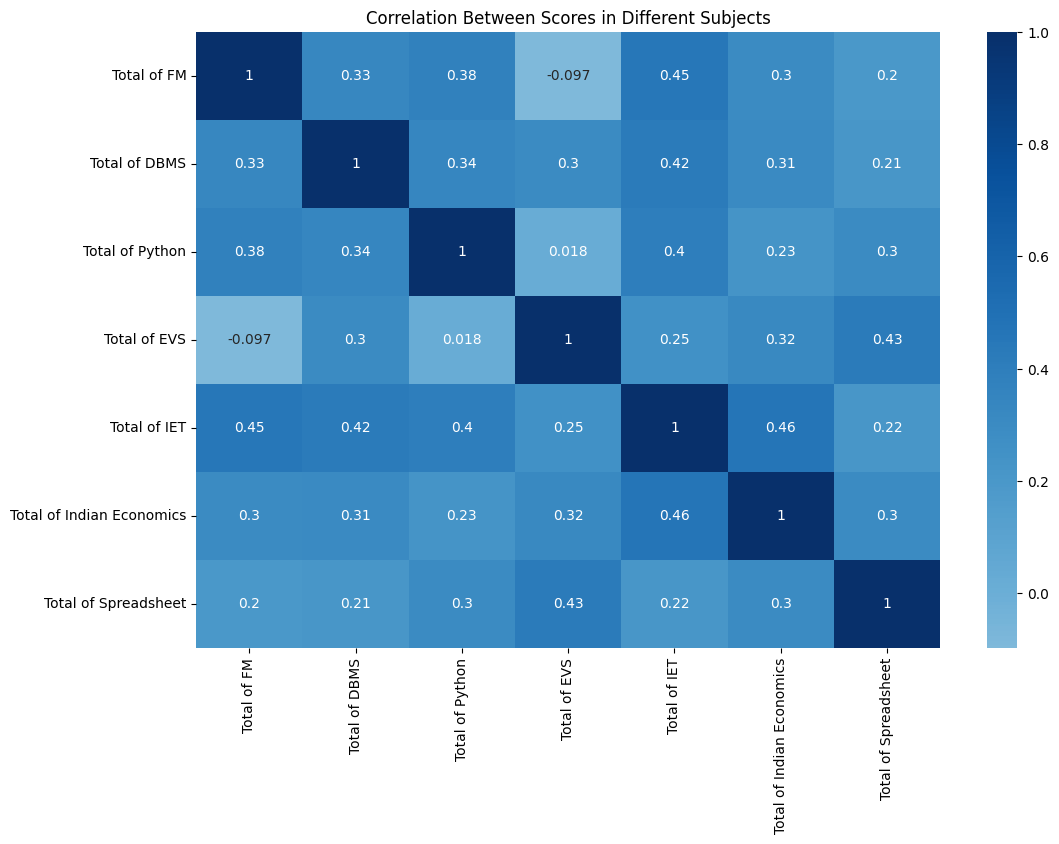

In [10]:
subject_correlations = totals_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(subject_correlations, annot=True, cmap='Blues', center=0)
plt.title('Correlation Between Scores in Different Subjects')
plt.show()

4 . Performace Insights :

In [11]:
variability = totals_df.std()
most_variable_subject = variability.idxmax()
highest_variability = variability.max()
print(f'The subject that shows the greatest variability in student performance: {most_variable_subject} with a variability of {highest_variability}')

The subject that shows the greatest variability in student performance: Total of FM with a variability of 11.859027144867111


In [12]:

mean_scores = totals_df.mean()
median_scores = totals_df.median()
better_performance_subjects = mean_scores[mean_scores > median_scores]
worse_performance_subjects = mean_scores[mean_scores < median_scores]
print('Subjects with consistently better performance:', better_performance_subjects)
print('Subjects with consistently worse performance:', worse_performance_subjects)

Subjects with consistently better performance: Series([], dtype: float64)
Subjects with consistently worse performance: Total of FM                  72.708333
Total of DBMS                72.270833
Total of Python              74.562500
Total of EVS                 72.645833
Total of IET                 73.416667
Total of Indian Economics    73.625000
Total of Spreadsheet         75.937500
dtype: float64


5 . Top and Bottom Performers:

In [13]:
df['Overall Total'] = totals_df.sum(axis=1)
top_performers = df.nlargest(5, 'Overall Total')[['Rollno', 'Name', 'Overall Total']]
print('Top-performing students across all subjects:', top_performers)

Top-performing students across all subjects:       Rollno            Name  Overall Total
40  BBA22230  Aditya Hisaria            617
0   BBA22006   Sharayu Dhale            581
42  BBA22248     Sidhi Oswal            574
14  BBA22020     Shubhashree            571
9   BBA22053  Mishruti Patel            570


In [14]:
struggling_subjects = avg_total_scores.nsmallest(3)
print('Subjects where students particularly struggle:', struggling_subjects)

Subjects where students particularly struggle: Total of DBMS    72.270833
Total of EVS     72.645833
Total of FM      72.708333
dtype: float64


6 . Trend Analysis:

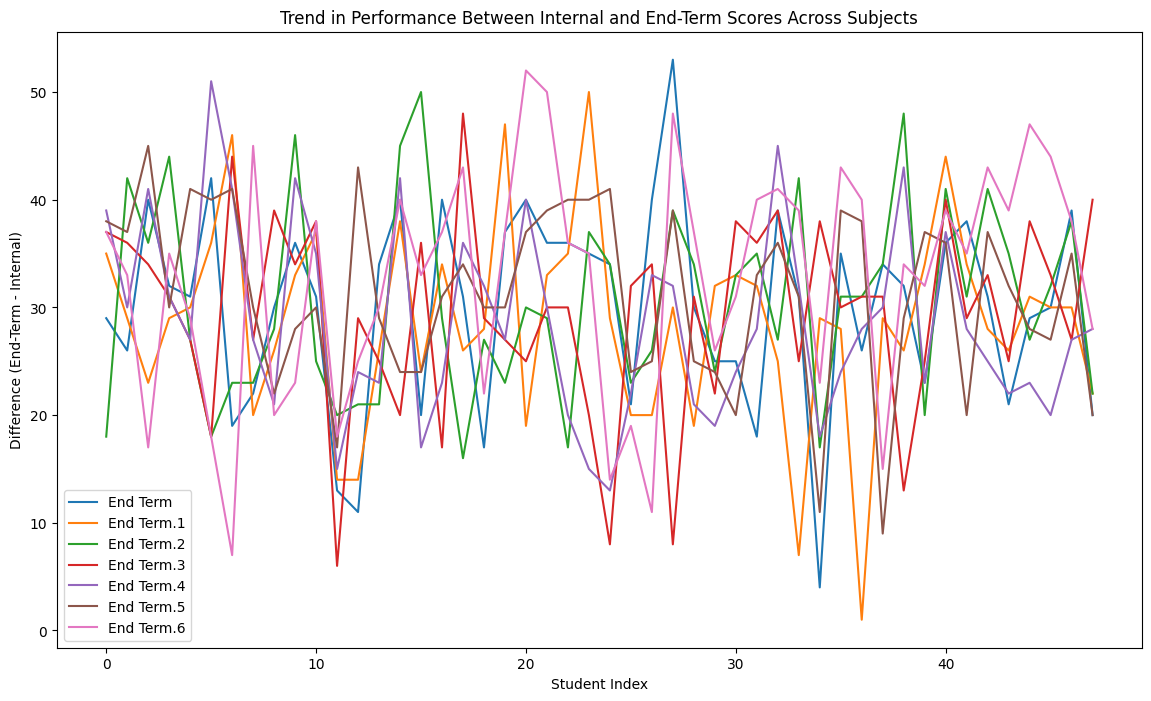

In [15]:
score_differences = df[end_term_columns].subtract(df[internal_columns].values)
plt.figure(figsize=(14, 8))
for col in score_differences.columns:
    sns.lineplot(data=score_differences[col], label=col)
plt.title('Trend in Performance Between Internal and End-Term Scores Across Subjects')
plt.xlabel('Student Index')
plt.ylabel('Difference (End-Term - Internal)')
plt.legend()
plt.show()

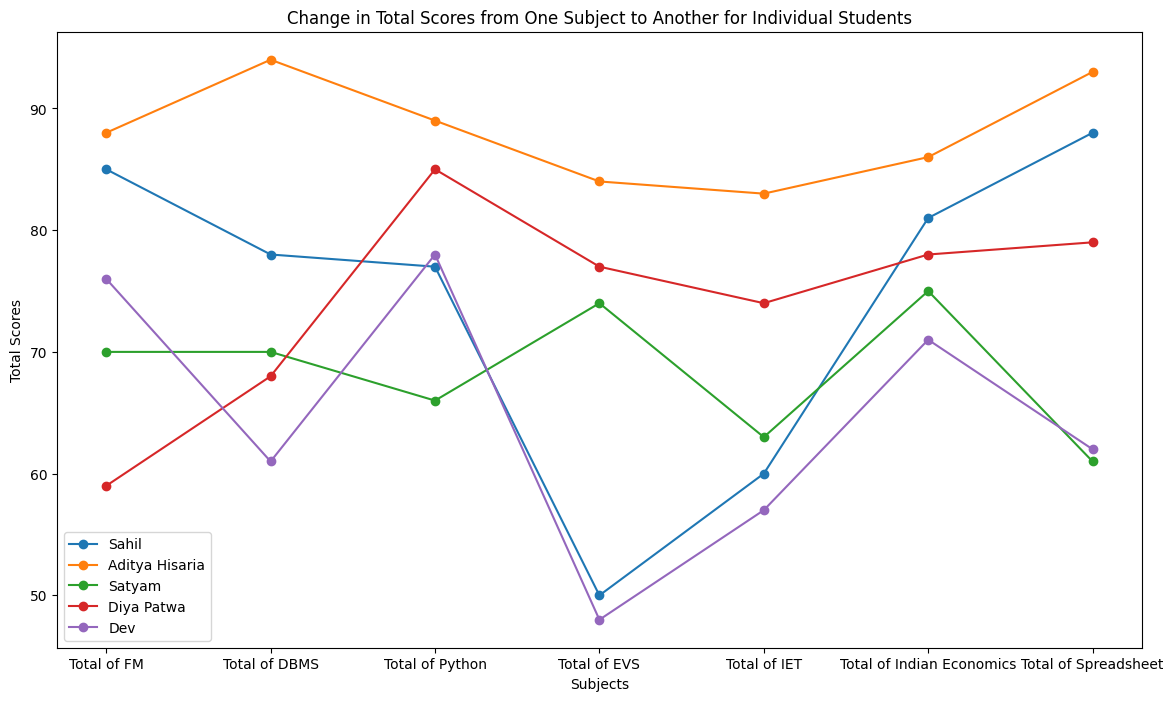

In [16]:
sample_students = df.sample(5, random_state=42)
plt.figure(figsize=(14, 8))
for index, row in sample_students.iterrows():
    plt.plot(totals_df.columns, row[total_scores_columns], marker='o', label=row['Name'])
plt.title('Change in Total Scores from One Subject to Another for Individual Students')
plt.xlabel('Subjects')
plt.ylabel('Total Scores')
plt.legend()
plt.show()

7 . Subject-wise Performance:

In [17]:

avg_internal_scores = df[internal_columns].mean()
highest_avg_internal_subject = avg_internal_scores.idxmax()
lowest_avg_internal_subject = avg_internal_scores.idxmin()
print(f'Subject with the highest average internal score: {highest_avg_internal_subject}')
print(f'Subject with the lowest average internal score: {lowest_avg_internal_subject}')

Subject with the highest average internal score: Internal.4
Subject with the lowest average internal score: Internal


In [18]:
avg_end_term_scores = df[end_term_columns].mean()
highest_avg_end_term_subject = avg_end_term_scores.idxmax()
lowest_avg_end_term_subject = avg_end_term_scores.idxmin()
print(f'Subject with the highest average end-term score: {highest_avg_end_term_subject}')
print(f'Subject with the lowest average end-term score: {lowest_avg_end_term_subject}')

Subject with the highest average end-term score: End Term.6
Subject with the lowest average end-term score: End Term.1


8 . Comparative Student Performance:

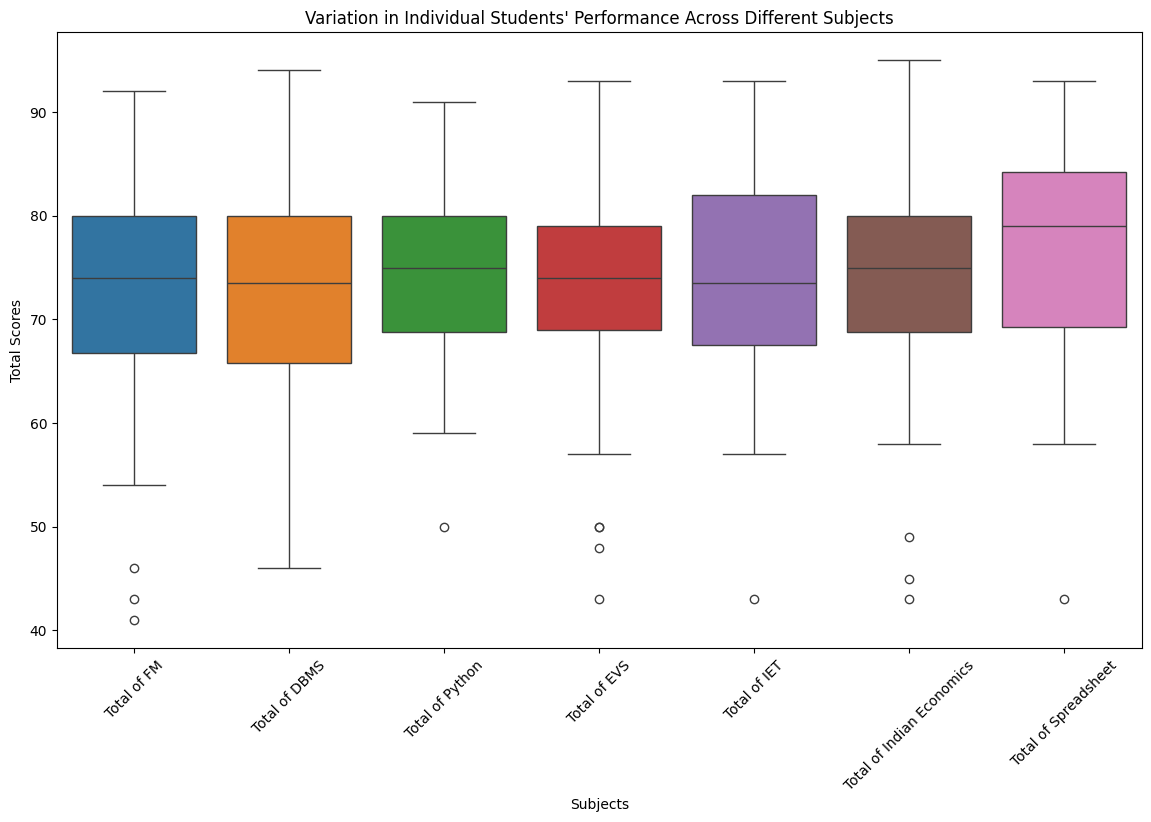

In [19]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=totals_df)
plt.title('Variation in Individual Students\' Performance Across Different Subjects')
plt.xlabel('Subjects')
plt.ylabel('Total Scores')
plt.xticks(rotation=45)
plt.show()

In [20]:
student_performance_variability = df[total_scores_columns].std(axis=1)
consistent_top_performers = df.loc[student_performance_variability.nsmallest(5).index, ['Rollno', 'Name', 'Overall Total']]
inconsistent_performers = df.loc[student_performance_variability.nlargest(5).index, ['Rollno', 'Name', 'Overall Total']]
print('Students who perform consistently well:', consistent_top_performers)
print('Students who have inconsistent performance:', inconsistent_performers)

Students who perform consistently well:       Rollno            Name  Overall Total
13  BBA22078     Sweta Gupta            536
45  BBA22255   Sneha Devhade            510
40  BBA22230  Aditya Hisaria            617
1   BBA22016     Vikramkumar            563
46  BBA22259    Komal Jangid            568
Students who have inconsistent performance:       Rollno          Name  Overall Total
12  BBA22069   Aryan Parde            483
38  BBA22224         Pooja            515
37  BBA22215         Aditi            464
27  BBA22145         Sahil            519
5   BBA22041  Shivam Kumar            519


9 . Predict Student Performance

In [21]:
X = df[['Internal']]
y = df['End Term']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Prediction Model - MSE: {mse}, R^2: {r2}')

Prediction Model - MSE: 97.1262299353194, R^2: 0.07141150100081273
